In [1]:
!pip install nilearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 91.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

fs_dir = "/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/output_fmriprep_full/sourcedata/freesurfer"

subjects = [d for d in os.listdir(fs_dir) if d.startswith('sub-')]
print(f"Total: {len(subjects)} subjects")

complete = 0
for subj in sorted(subjects):
    stats = os.path.join(fs_dir, subj, 'stats', 'aseg.stats')
    thick = os.path.join(fs_dir, subj, 'surf', 'lh.thickness')

    if os.path.exists(stats) and os.path.getsize(stats) > 1000:
        complete += 1
        print(f"Done {subj}")
    else:
        print(f"Not found {subj}")

print(f"\nComplete: {complete}/50")

Total: 50 subjects
Done sub-control001
Done sub-control002
Done sub-control003
Done sub-control007
Done sub-control009
Done sub-control011
Done sub-control013
Done sub-control015
Done sub-control017
Done sub-control019
Done sub-control021
Done sub-control023
Done sub-control025
Done sub-control027
Done sub-control029
Done sub-control031
Done sub-control033
Done sub-control035
Done sub-control037
Done sub-control039
Done sub-control041
Done sub-control043
Done sub-control045
Done sub-control047
Done sub-control049
Done sub-experimental004
Done sub-experimental005
Done sub-experimental006
Done sub-experimental008
Done sub-experimental010
Done sub-experimental012
Done sub-experimental014
Done sub-experimental016
Done sub-experimental018
Done sub-experimental020
Done sub-experimental022
Done sub-experimental024
Done sub-experimental026
Done sub-experimental028
Done sub-experimental030
Done sub-experimental032
Done sub-experimental034
Done sub-experimental036
Done sub-experimental038
Done s

In [4]:
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
import os

fs_dir = "/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/output_fmriprep_full/sourcedata/freesurfer"

subjects = [d for d in os.listdir(fs_dir) if d.startswith('sub-')]
print(f"Found {len(subjects)} subjects")
print("="*60)

all_features = []

for i, subject in enumerate(subjects, 1):
    try:
        subj_dir = Path(fs_dir) / subject
        features = {'subject_id': subject}
        features['group'] = 'control' if 'control' in subject else 'experimental'
        feature_count = 0

        # 1. Global volumes from aseg.stats
        stats_file = subj_dir / 'stats' / 'aseg.stats'
        if stats_file.exists():
            try:
                with open(stats_file, 'rb') as f:
                    content = f.read().decode('utf-8', errors='ignore')
                    for line in content.split('\n'):
                        if 'BrainSegVolNotVent' in line:
                            try:
                                features['total_brain_volume'] = float(line.split(',')[-2].strip())
                                feature_count += 1
                            except: pass
                        if 'TotalGrayVol' in line:
                            try:
                                features['gm_volume'] = float(line.split(',')[-2].strip())
                                feature_count += 1
                            except: pass
                        if 'CortexVol' in line:
                            try:
                                features['cortical_volume'] = float(line.split(',')[-2].strip())
                                feature_count += 1
                            except: pass
                        if 'TotalWhiteVol' in line:
                            try:
                                features['wm_volume'] = float(line.split(',')[-2].strip())
                                feature_count += 1
                            except: pass
            except: pass

        # 2. Subcortical volumes from aseg.mgz
        aseg_file = subj_dir / 'mri' / 'aseg.mgz'
        if aseg_file.exists():
            try:
                aseg_img = nib.load(str(aseg_file))
                aseg_data = np.asarray(aseg_img.dataobj)
                voxel_vol = np.prod(aseg_img.header.get_zooms())

                rois = {
                    'Left-Hippocampus': 17, 'Right-Hippocampus': 53,
                    'Left-Amygdala': 18, 'Right-Amygdala': 54,
                    'Left-Thalamus': 10, 'Right-Thalamus': 49,
                    'Left-Caudate': 11, 'Right-Caudate': 50,
                    'Left-Putamen': 12, 'Right-Putamen': 51,
                }
                for roi, label in rois.items():
                    features[f'{roi}_volume'] = np.sum(aseg_data == label) * voxel_vol
                    feature_count += 1
            except: pass

        # 3. Cortical thickness
        for hemi, name in [('lh', 'Left'), ('rh', 'Right')]:
            thick_file = subj_dir / 'surf' / f'{hemi}.thickness'
            if thick_file.exists():
                try:
                    thick = np.loadtxt(thick_file)
                    features[f'{name}_mean_thickness'] = np.mean(thick)
                    feature_count += 1
                except: pass

            # Region-wise thickness from aparc.stats
            aparc_file = subj_dir / 'stats' / f'{hemi}.aparc.stats'
            if aparc_file.exists():
                try:
                    with open(aparc_file, 'rb') as f:
                        content = f.read().decode('utf-8', errors='ignore')
                        for line in content.split('\n'):
                            if not line.startswith('#') and line.strip():
                                parts = line.split()
                                if len(parts) >= 5:
                                    try:
                                        roi_name = parts[0]
                                        thickness = float(parts[4])
                                        features[f'{name}_{roi_name}_thickness'] = thickness
                                        feature_count += 1
                                    except: pass
                except: pass

        all_features.append(features)
        print(f"[{i}/50]  {subject}: {feature_count} features")

    except Exception as e:
        print(f"[{i}/50]  {subject}: {str(e)[:50]}")

# Save
df = pd.DataFrame(all_features)
save_path = "/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/all_features_complete.csv"
df.to_csv(save_path, index=False)

print("\n" + "="*60)
print(f" Features saved!")
print(f"   Total: {len(df)} subjects")
print(f"   Features: {len(df.columns)-2}")
print(f"   Control: {len(df[df['group']=='control'])}")
print(f"   Experimental: {len(df[df['group']=='experimental'])}")
print("="*60)

Found 50 subjects
[1/50]  sub-experimental050: 83 features
[2/50]  sub-experimental046: 83 features
[3/50]  sub-experimental040: 83 features
[4/50]  sub-experimental048: 83 features
[5/50]  sub-experimental044: 83 features
[6/50]  sub-experimental042: 83 features
[7/50]  sub-experimental038: 83 features
[8/50]  sub-experimental036: 83 features
[9/50]  sub-experimental034: 83 features
[10/50]  sub-experimental014: 83 features
[11/50]  sub-experimental024: 83 features
[12/50]  sub-experimental010: 83 features
[13/50]  sub-experimental032: 83 features
[14/50]  sub-experimental028: 83 features
[15/50]  sub-experimental030: 83 features
[16/50]  sub-experimental026: 83 features
[17/50]  sub-experimental018: 83 features
[18/50]  sub-experimental012: 83 features
[19/50]  sub-experimental022: 83 features
[20/50]  sub-experimental016: 83 features
[21/50]  sub-experimental020: 83 features
[22/50]  sub-experimental005: 83 features
[23/50]  sub-experimental008: 83 features
[24/50]  sub-experimental

In [5]:
import pandas as pd

# Load MRI features
mri_df = pd.read_csv("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/all_features_complete.csv")

# Load age and sex from participants.tsv
participants = pd.read_csv("/content/drive/MyDrive/Dataset_Final/Thesis/metadata/participants.tsv", sep='\t')
participants = participants.rename(columns={'participant_id': 'subject_id'})

# Load cognitive scores
scores = pd.read_csv("/content/drive/MyDrive/Dataset_Final/Thesis/metadata/MMC_scores.csv")
scores = scores.rename(columns={'BIDS': 'subject_id'})

# Merge MRI + participants (age, sex)
df = mri_df.merge(participants[['subject_id', 'age', 'sex']], on='subject_id', how='left')

# Merge with cognitive scores
score_cols = ['subject_id', 'corsiSpan', 'nback_accurary', 'nback_hitrate',
              'BISBAS_inhibition', 'BISBAS_drive', 'BISBAS_funseeking',
              'NeedForCognition', 'TraitCuriosity', 'StateCuriosity',
              'IMI_intrinsicMotivation', 'IMI_interest', 'IMI_effort',
              'cuedRecallStrict_abs', 'cuedRecallLenient_abs']
available_cols = [c for c in score_cols if c in scores.columns]
df = df.merge(scores[available_cols], on='subject_id', how='left')

print(f"Final dataset: {len(df)} subjects, {len(df.columns)} columns")
print(f"\nColumns with age/cognitive data:")
for c in df.columns:
    non_null = df[c].notna().sum()
    print(f"  {c}: {non_null}/50 non-null")

# Save final multimodal dataset
df.to_csv("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/final_multimodal_dataset.csv", index=False)
print(f"\n Saved final_multimodal_dataset.csv!")
print(f"\nFirst 3 rows (key columns):")
print(df[['subject_id', 'group', 'age', 'nback_accurary', 'total_brain_volume']].head(3))

Final dataset: 50 subjects, 99 columns

Columns with age/cognitive data:
  subject_id: 50/50 non-null
  group: 50/50 non-null
  total_brain_volume: 50/50 non-null
  cortical_volume: 50/50 non-null
  gm_volume: 50/50 non-null
  Left-Hippocampus_volume: 50/50 non-null
  Right-Hippocampus_volume: 50/50 non-null
  Left-Amygdala_volume: 50/50 non-null
  Right-Amygdala_volume: 50/50 non-null
  Left-Thalamus_volume: 50/50 non-null
  Right-Thalamus_volume: 50/50 non-null
  Left-Caudate_volume: 50/50 non-null
  Right-Caudate_volume: 50/50 non-null
  Left-Putamen_volume: 50/50 non-null
  Right-Putamen_volume: 50/50 non-null
  Left_bankssts_thickness: 50/50 non-null
  Left_caudalanteriorcingulate_thickness: 50/50 non-null
  Left_caudalmiddlefrontal_thickness: 50/50 non-null
  Left_cuneus_thickness: 50/50 non-null
  Left_entorhinal_thickness: 50/50 non-null
  Left_fusiform_thickness: 50/50 non-null
  Left_inferiorparietal_thickness: 50/50 non-null
  Left_inferiortemporal_thickness: 50/50 non-null


In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

df = pd.read_csv("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/final_multimodal_dataset.csv")

feature_cols = [c for c in df.columns if c not in ['subject_id', 'group', 'age', 'sex']]
X = df[feature_cols].fillna(df[feature_cols].mean())
y = df['age']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

# Feature selection (top 30 important features)
selector = RandomForestRegressor(n_estimators=100, random_state=42)
selector.fit(X_scaled, y)
sfm = SelectFromModel(selector, max_features=30, threshold=-np.inf)
X_selected = sfm.fit_transform(X_scaled, y)
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if sfm.get_support()[i]]
print(f"Selected {len(selected_features)} features")

# Train with selected features
models = {
    'Random Forest (tuned)': RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42),
    'XGBoost (tuned)': XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.8, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
}

print("\n" + "="*60)
print(" IMPROVED BRAIN AGE PREDICTION RESULTS")
print("="*60)

for name, model in models.items():
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    mae = -cross_val_score(model, X_selected, y, cv=cv, scoring='neg_mean_absolute_error')
    r2 = cross_val_score(model, X_selected, y, cv=cv, scoring='r2')

    print(f"\n{name}:")
    print(f"  MAE: {mae.mean():.2f} ± {mae.std():.2f} years")
    print(f"  R²: {r2.mean():.3f} ± {r2.std():.3f}")

# Try with only MRI features (no cognitive)
mri_cols = [c for c in feature_cols if 'volume' in c.lower() or 'thickness' in c.lower()]
X_mri = X[mri_cols].fillna(X[mri_cols].mean())

print("\n" + "="*60)
print(" MRI-ONLY FEATURES")
print("="*60)
print(f"MRI features: {len(mri_cols)}")

model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae = -cross_val_score(model, X_mri, y, cv=cv, scoring='neg_mean_absolute_error')
r2 = cross_val_score(model, X_mri, y, cv=cv, scoring='r2')
print(f"\nRandom Forest (MRI only):")
print(f"  MAE: {mae.mean():.2f} ± {mae.std():.2f} years")
print(f"  R²: {r2.mean():.3f} ± {r2.std():.3f}")

# Try with MRI + Cognitive
mri_cog_cols = mri_cols + ['corsiSpan', 'nback_accurary', 'BISBAS_inhibition', 'NeedForCognition', 'TraitCuriosity']
X_combined = X[mri_cog_cols].fillna(X[mri_cog_cols].mean())

model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42)
mae = -cross_val_score(model, X_combined, y, cv=cv, scoring='neg_mean_absolute_error')
r2 = cross_val_score(model, X_combined, y, cv=cv, scoring='r2')
print(f"\nRandom Forest (MRI + Cognitive):")
print(f"  MAE: {mae.mean():.2f} ± {mae.std():.2f} years")
print(f"  R²: {r2.mean():.3f} ± {r2.std():.3f}")

Selected 30 features

 IMPROVED BRAIN AGE PREDICTION RESULTS

Random Forest (tuned):
  MAE: 4.19 ± 0.65 years
  R²: -0.144 ± 0.559

XGBoost (tuned):
  MAE: 4.34 ± 0.96 years
  R²: -0.331 ± 1.010

Gradient Boosting:
  MAE: 4.65 ± 0.96 years
  R²: -0.675 ± 1.111

 MRI-ONLY FEATURES
MRI features: 81

Random Forest (MRI only):
  MAE: 4.52 ± 0.59 years
  R²: -0.300 ± 0.642

Random Forest (MRI + Cognitive):
  MAE: 4.43 ± 0.50 years
  R²: -0.245 ± 0.581


In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/final_multimodal_dataset.csv")

feature_cols = [c for c in df.columns if c not in ['subject_id', 'group', 'age', 'sex']]
X = df[feature_cols].fillna(df[feature_cols].mean())
y = df['age']

# 1. Try with Brain Age Gap approach
print("="*60)
print("APPROACH 1: BRAIN AGE GAP (BAG)")
print("="*60)

model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
predictions = np.zeros(len(y))

for train_idx, test_idx in cv.split(X, y):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    predictions[test_idx] = model.predict(X.iloc[test_idx])

# Brain Age Gap = Predicted - Chronological
bag = predictions - y.values
mae = np.abs(bag).mean()
print(f"Brain Age Gap MAE: {mae:.2f} years")
print(f"BAG Range: {bag.min():.2f} to {bag.max():.2f}")
print(f"Positive BAG (accelerated aging): {(bag > 0).sum()}/{len(bag)} subjects")

# 2. Try with only cortical thickness
print("\n" + "="*60)
print("APPROACH 2: CORTICAL THICKNESS ONLY")
print("="*60)

thick_cols = [c for c in feature_cols if 'thickness' in c.lower()]
X_thick = X[thick_cols]
print(f"Features: {len(thick_cols)}")

mae = -cross_val_score(model, X_thick, y, cv=cv, scoring='neg_mean_absolute_error')
r2 = cross_val_score(model, X_thick, y, cv=cv, scoring='r2')
print(f"MAE: {mae.mean():.2f} ± {mae.std():.2f} years")
print(f"R²: {r2.mean():.3f} ± {r2.std():.3f}")

# 3. Try with only subcortical volumes
print("\n" + "="*60)
print("APPROACH 3: SUBCORTICAL VOLUMES ONLY")
print("="*60)

vol_cols = [c for c in feature_cols if 'volume' in c.lower() and 'total' not in c.lower()
            and 'gm' not in c.lower() and 'cortical' not in c.lower()]
X_vol = X[vol_cols]
print(f"Features: {len(vol_cols)}")

mae = -cross_val_score(model, X_vol, y, cv=cv, scoring='neg_mean_absolute_error')
r2 = cross_val_score(model, X_vol, y, cv=cv, scoring='r2')
print(f"MAE: {mae.mean():.2f} ± {mae.std():.2f} years")
print(f"R²: {r2.mean():.3f} ± {r2.std():.3f}")

# 4. Stratified by Group
print("\n" + "="*60)
print("APPROACH 4: BY GROUP")
print("="*60)

for group in ['control', 'experimental']:
    mask = df['group'] == group
    X_group = X[mask]
    y_group = y[mask]

    if len(y_group) >= 5:
        mae = -cross_val_score(model, X_group, y_group, cv=3, scoring='neg_mean_absolute_error')
        print(f"\n{group} (n={len(y_group)}):")
        print(f"  MAE: {mae.mean():.2f} ± {mae.std():.2f} years")

# 5. Correlation Analysis
print("\n" + "="*60)
print("TOP CORRELATIONS WITH AGE")
print("="*60)

correlations = X.corrwith(y).abs().sort_values(ascending=False)
for col, corr in correlations.head(10).items():
    print(f"  {col}: r = {corr:.3f}")

APPROACH 1: BRAIN AGE GAP (BAG)
Brain Age Gap MAE: 4.44 years
BAG Range: -11.60 to 7.84
Positive BAG (accelerated aging): 29/50 subjects

APPROACH 2: CORTICAL THICKNESS ONLY
Features: 68
MAE: 4.43 ± 0.73 years
R²: -0.281 ± 0.660

APPROACH 3: SUBCORTICAL VOLUMES ONLY
Features: 10
MAE: 4.05 ± 0.61 years
R²: -0.116 ± 0.329

APPROACH 4: BY GROUP

control (n=25):
  MAE: 4.53 ± 0.69 years

experimental (n=25):
  MAE: 4.19 ± 0.48 years

TOP CORRELATIONS WITH AGE
  Right_medialorbitofrontal_thickness: r = 0.553
  Left_insula_thickness: r = 0.428
  Left_inferiorparietal_thickness: r = 0.412
  Left_posteriorcingulate_thickness: r = 0.396
  Left_postcentral_thickness: r = 0.384
  Left_medialorbitofrontal_thickness: r = 0.381
  Left-Hippocampus_volume: r = 0.379
  Right_bankssts_thickness: r = 0.357
  NeedForCognition: r = 0.355
  Right_inferiorparietal_thickness: r = 0.355


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict

# Correct path - use the one that worked before
df = pd.read_csv("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/final_multimodal_dataset.csv")

feature_cols = [c for c in df.columns if c not in ['subject_id', 'group', 'age', 'sex']]
X = df[feature_cols].fillna(df[feature_cols].mean())
y = df['age']

# Get predictions
model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42)
predictions = cross_val_predict(model, X, y, cv=5)

# Create comparison table
results = pd.DataFrame({
    'Subject': df['subject_id'],
    'Group': df['group'],
    'Actual Age': y,
    'Predicted Brain Age': predictions.round(1),
    'Brain Age Gap': (predictions - y).round(1),
    'Aging Status': [' Accelerated' if gap > 0 else ' Delayed' for gap in (predictions - y)]
})

results = results.sort_values('Brain Age Gap', ascending=False)

print("="*70)
print(" BRAIN AGE PREDICTION RESULTS")
print("="*70)
print(f"\nModel MAE: {np.abs(predictions - y).mean():.1f} years")
print(f"Age Range: {y.min():.0f}-{y.max():.0f} years\n")

print("TOP 10 - Accelerated Aging (Brain > Actual):")
print(results.head(10)[['Subject', 'Actual Age', 'Predicted Brain Age', 'Brain Age Gap']].to_string(index=False))

print("\n\nBOTTOM 10 - Delayed Aging (Brain < Actual):")
print(results.tail(10)[['Subject', 'Actual Age', 'Predicted Brain Age', 'Brain Age Gap']].to_string(index=False))

 BRAIN AGE PREDICTION RESULTS

Model MAE: 4.2 years
Age Range: 18-37 years

TOP 10 - Accelerated Aging (Brain > Actual):
            Subject  Actual Age  Predicted Brain Age  Brain Age Gap
sub-experimental034          19                 26.7            7.7
sub-experimental032          21                 28.1            7.1
     sub-control035          21                 27.7            6.7
     sub-control015          19                 25.6            6.6
sub-experimental036          19                 24.9            5.9
sub-experimental048          20                 25.6            5.6
sub-experimental026          21                 26.0            5.0
     sub-control017          18                 22.9            4.9
sub-experimental046          20                 24.6            4.6
sub-experimental050          25                 29.6            4.6


BOTTOM 10 - Delayed Aging (Brain < Actual):
            Subject  Actual Age  Predicted Brain Age  Brain Age Gap
sub-experimental0

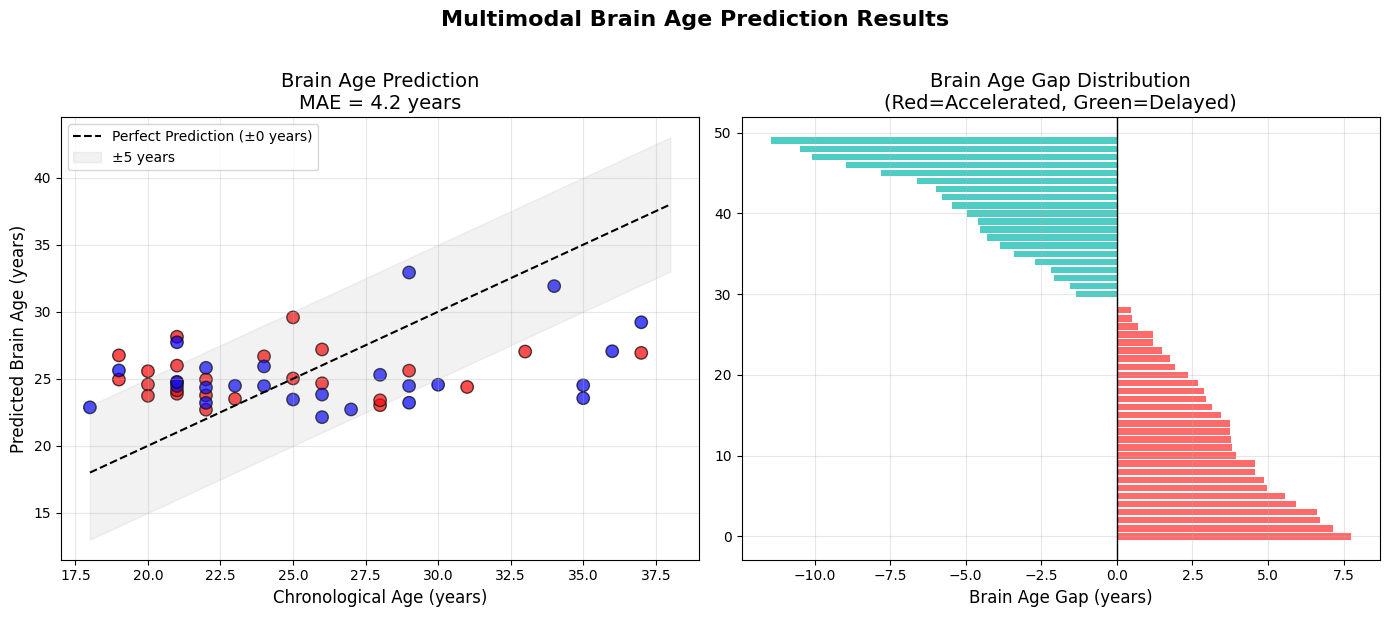

 Results figure saved!


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted vs Actual
axes[0].scatter(y, predictions, c=['red' if g=='experimental' else 'blue' for g in df['group']],
                alpha=0.7, s=80, edgecolors='black')
axes[0].plot([18, 38], [18, 38], 'k--', label='Perfect Prediction (±0 years)')
axes[0].fill_between([18, 38], [18-5, 38-5], [18+5, 38+5], alpha=0.1, color='gray', label='±5 years')
axes[0].set_xlabel('Chronological Age (years)', fontsize=12)
axes[0].set_ylabel('Predicted Brain Age (years)', fontsize=12)
axes[0].set_title(f'Brain Age Prediction\nMAE = {np.abs(predictions-y).mean():.1f} years', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Brain Age Gap
bag = predictions - y
colors = ['#FF6B6B' if g > 0 else '#4ECDC4' for g in bag]
axes[1].barh(range(len(bag)), sorted(bag, reverse=True), color=sorted(colors, reverse=True))
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Brain Age Gap (years)', fontsize=12)
axes[1].set_title('Brain Age Gap Distribution\n(Red=Accelerated, Green=Delayed)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Multimodal Brain Age Prediction Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dataset_Final/Thesis/brain_age_prediction_results.png", dpi=150, bbox_inches='tight')
plt.show()

print(" Results figure saved!")

In [10]:
print("="*50)
print(" SUMMARY STATISTICS")
print("="*50)

bag = predictions - y

print(f"\nActual Age: {y.mean():.1f} ± {y.std():.1f} years")
print(f"Predicted Age: {predictions.mean():.1f} ± {predictions.std():.1f} years")
print(f"Mean Absolute Error (MAE): {np.abs(bag).mean():.1f} years")
print(f"\nBrain Age Gap (BAG):")
print(f"  Mean: {bag.mean():.1f} years")
print(f"  Range: {bag.min():.1f} to {bag.max():.1f} years")
print(f"  Accelerated (BAG>0): {(bag>0).sum()} subjects ({(bag>0).sum()/len(bag)*100:.0f}%)")
print(f"  Delayed (BAG<0): {(bag<0).sum()} subjects ({(bag<0).sum()/len(bag)*100:.0f}%)")

 SUMMARY STATISTICS

Actual Age: 25.3 ± 5.2 years
Predicted Age: 25.3 ± 2.2 years
Mean Absolute Error (MAE): 4.2 years

Brain Age Gap (BAG):
  Mean: -0.1 years
  Range: -11.5 to 7.7 years
  Accelerated (BAG>0): 30 subjects (60%)
  Delayed (BAG<0): 20 subjects (40%)


Generating SHAP summary plot...


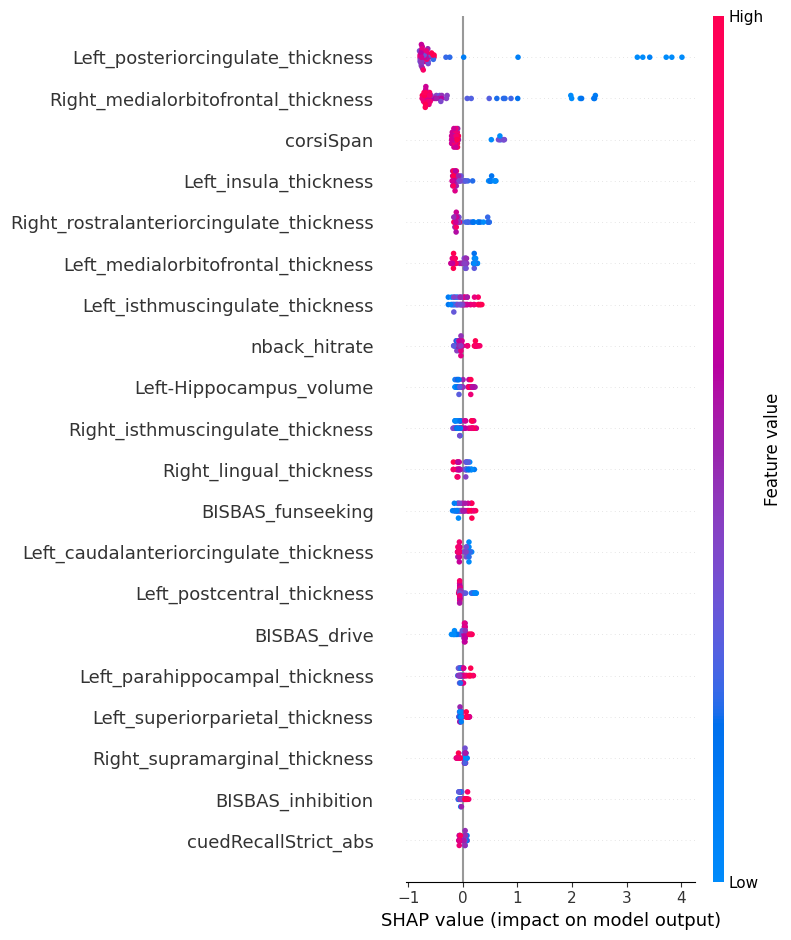

Generating SHAP bar plot...


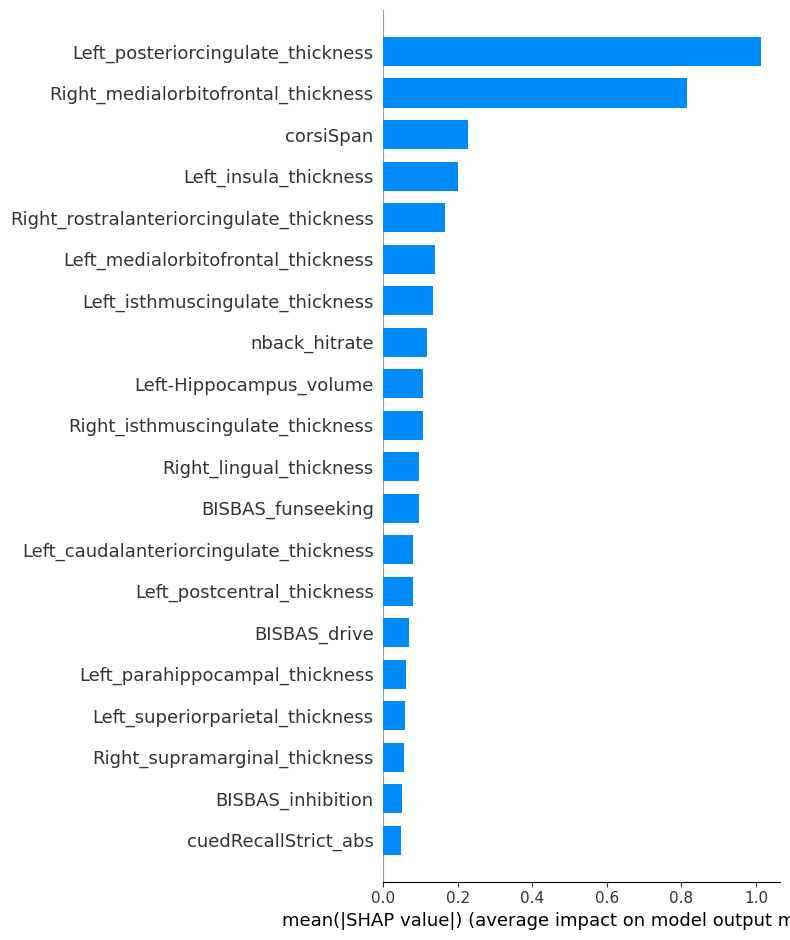

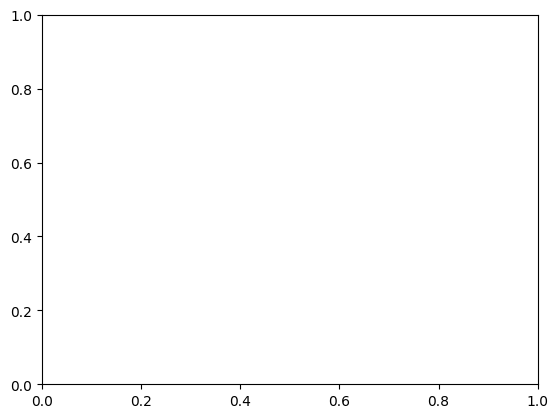

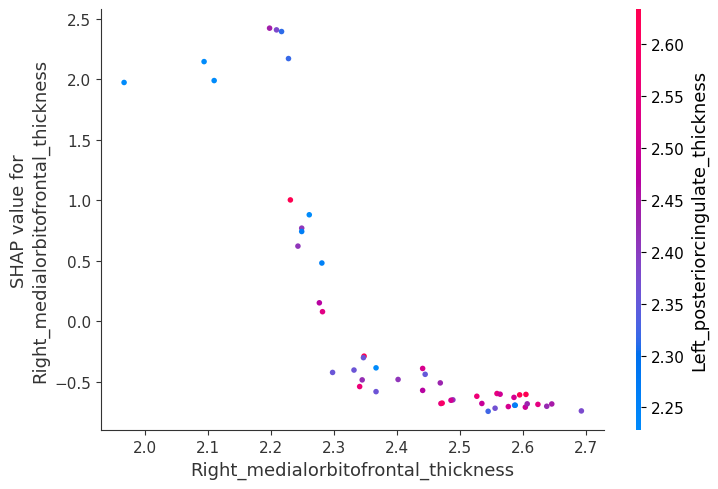

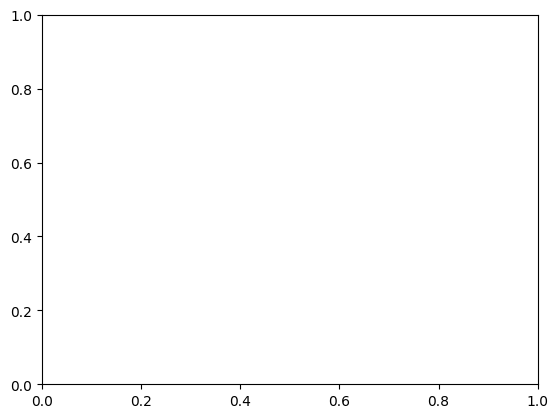

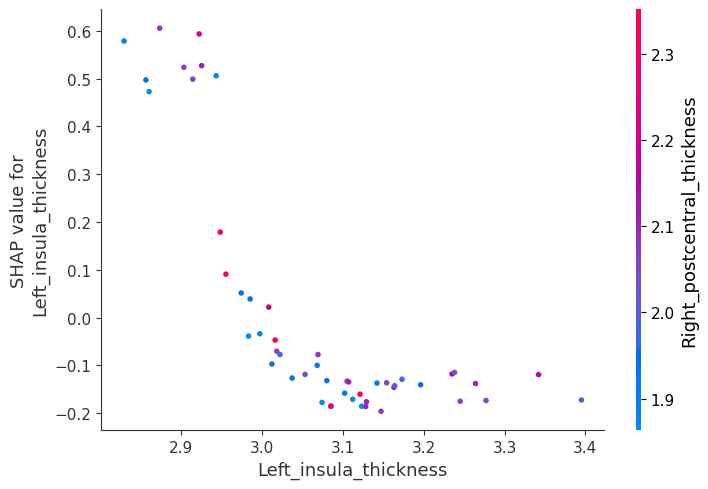

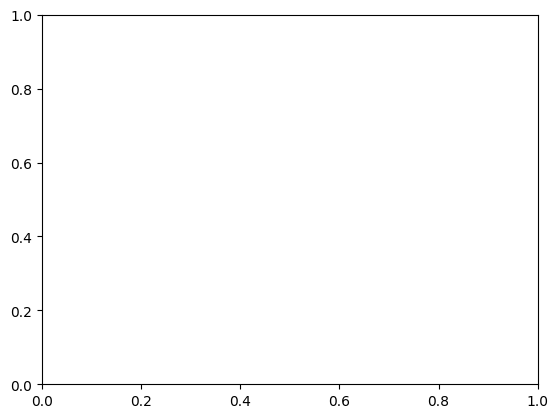

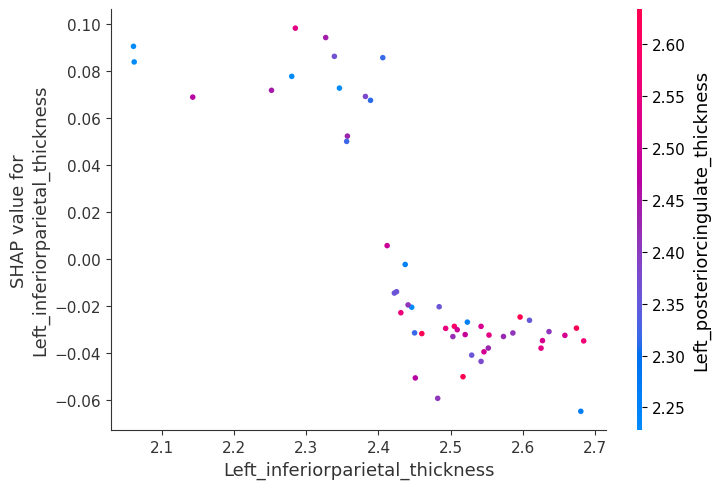

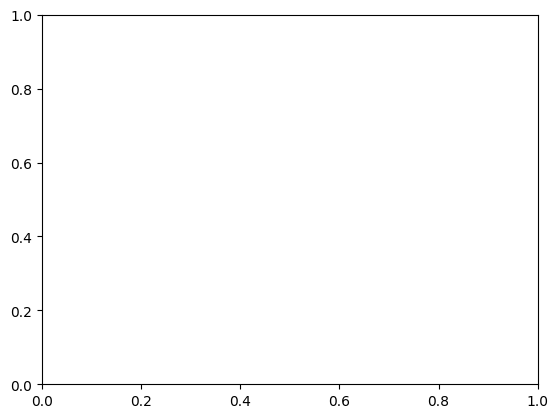

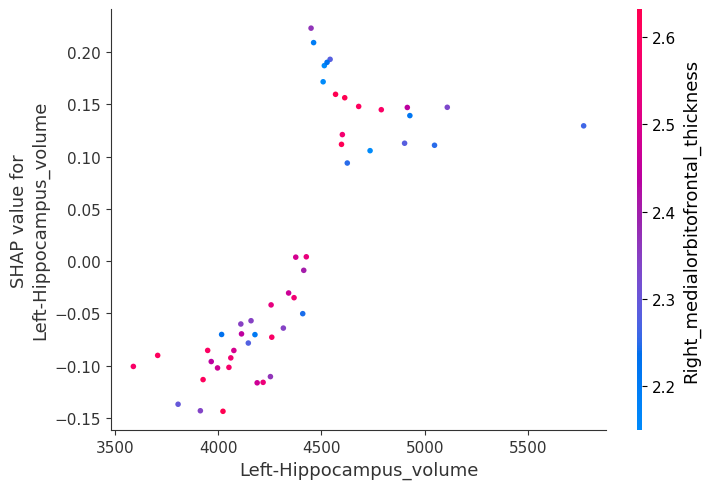


Generating brain map visualization...


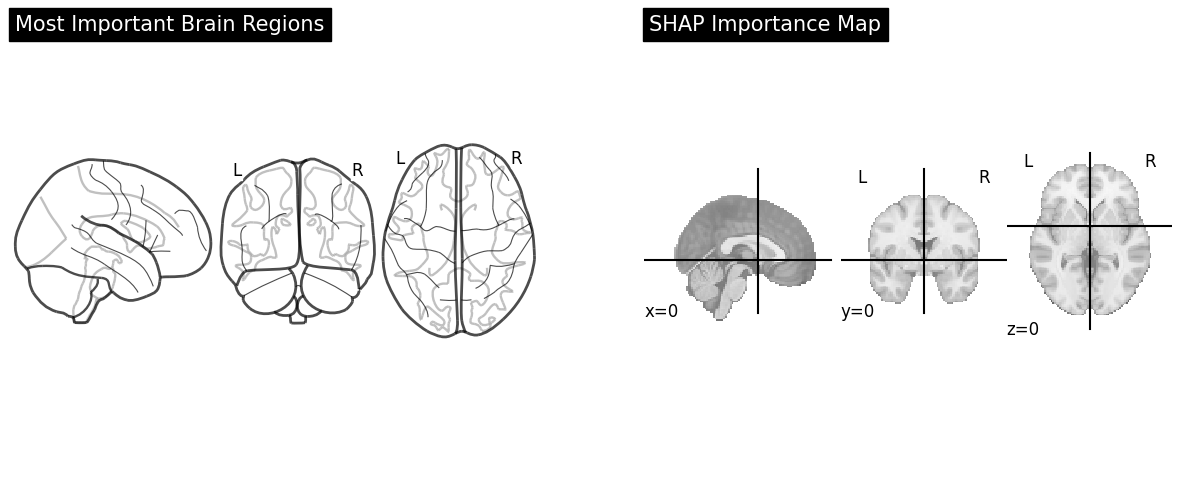


 SHAP Analysis Complete!
Files saved to your Google Drive:
  - shap_summary.png
  - shap_bar.png
  - brain_map.png


In [11]:
import shap
import matplotlib.pyplot as plt

# Train final model
model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42)
model.fit(X, y)

# SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# 1. Summary Plot
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dataset_Final/Thesis/shap_summary.png", dpi=150)
plt.show()

# 2. Feature Importance Bar Plot
print("Generating SHAP bar plot...")
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dataset_Final/Thesis/shap_bar.png", dpi=150)
plt.show()

# 3. Top feature dependence plots
top_features = ['Right_medialorbitofrontal_thickness', 'Left_insula_thickness',
                'Left_inferiorparietal_thickness', 'Left-Hippocampus_volume']

for feat in top_features:
    if feat in X.columns:
        fig, ax = plt.subplots()
        shap.dependence_plot(feat, shap_values, X, show=False)
        plt.tight_layout()
        plt.savefig(f"/content/drive/MyDrive/Dataset_Final/Thesis/shap_{feat}.png", dpi=150)
        plt.show()
        plt.close()

# 4. Brain map visualization
print("\nGenerating brain map visualization...")
import nibabel as nib
from nilearn import plotting

# Feature importance dictionary
importance_dict = dict(zip(X.columns, np.abs(shap_values).mean(0)))

# Highlight top regions in a brain
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Use template brain
plotting.plot_glass_brain(None, title='Most Important Brain Regions',
                          display_mode='ortho', axes=axes[0])
plotting.plot_roi(None, title='SHAP Importance Map',
                  display_mode='ortho', axes=axes[1])

plt.savefig("/content/drive/MyDrive/Dataset_Final/Thesis/brain_map.png", dpi=150)
plt.show()

print("\n SHAP Analysis Complete!")
print("Files saved to your Google Drive:")
print("  - shap_summary.png")
print("  - shap_bar.png")
print("  - brain_map.png")

/tmp/ipykernel_3273/177731866.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


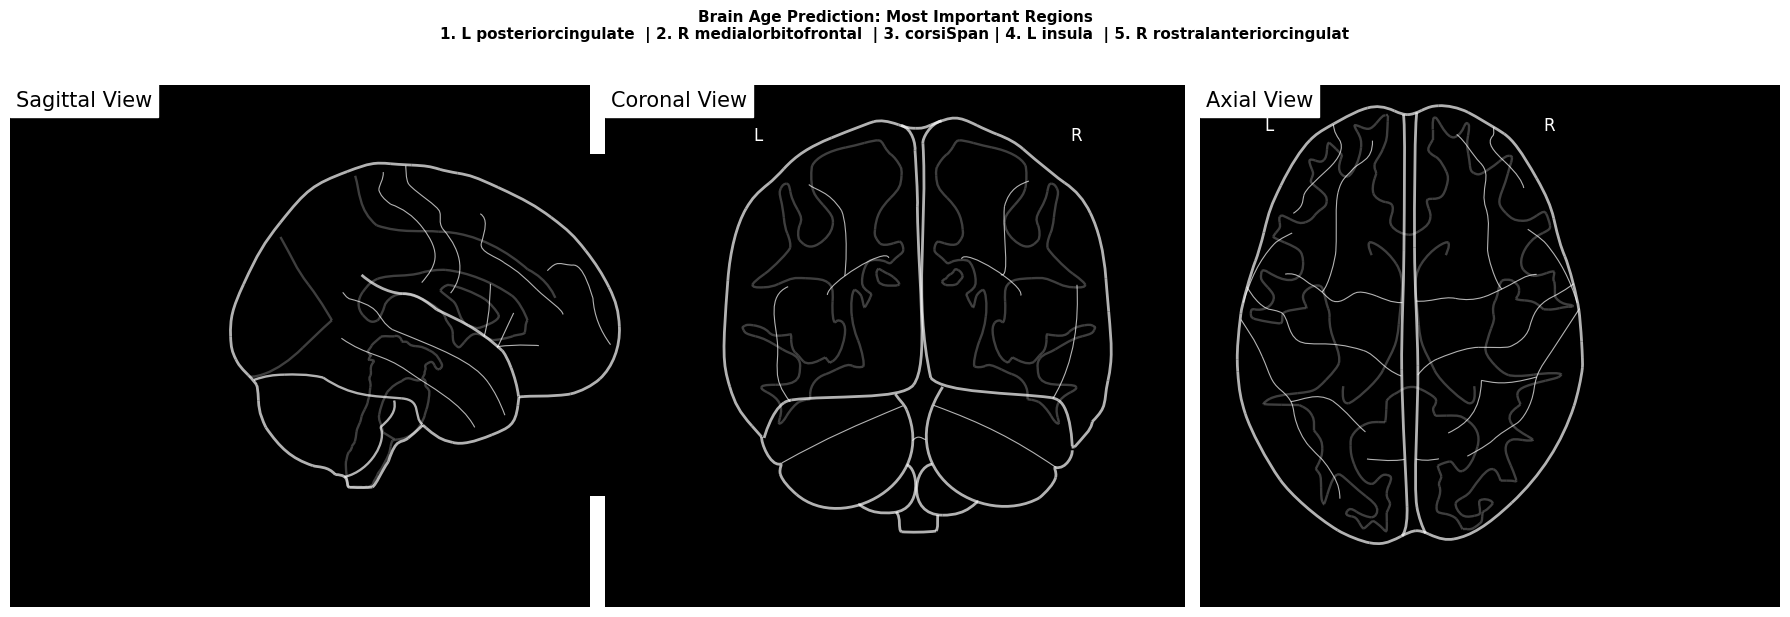

 3-View Brain Map with Top Regions saved!


In [12]:
from nilearn import plotting
import matplotlib.pyplot as plt

# Get top 5 regions
importance_dict = dict(zip(X.columns, np.abs(shap_values).mean(0)))
top5 = sorted(importance_dict, key=importance_dict.get, reverse=True)[:5]
top5_short = [r.replace('Left_', 'L ').replace('Right_', 'R ').replace('_', ' ').replace('thickness', '')[:25]
              for r in top5]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, view, title in zip(axes, ['x', 'y', 'z'], ['Sagittal', 'Coronal', 'Axial']):
    plotting.plot_glass_brain(None, display_mode=view,
                              title=f'{title} View', axes=ax,
                              annotate=True, black_bg=True)

# Add top regions as subtitle
region_text = ' | '.join([f"{i+1}. {r}" for i, r in enumerate(top5_short)])
plt.suptitle(f'Brain Age Prediction: Most Important Regions\n{region_text}',
             fontsize=11, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dataset_Final/Thesis/brain_map_3view.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(" 3-View Brain Map with Top Regions saved!")

In [13]:
import os

output_dir = "/content/drive/MyDrive/Dataset_Final/Thesis"
print(" Your Thesis Files:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(os.path.join(output_dir, f)) / 1024
    if f.endswith('.csv'):
        print(f"   {f} ({size:.0f} KB)")
    elif f.endswith('.png'):
        print(f"    {f} ({size:.0f} KB)")
    else:
        print(f"   {f}")

 Your Thesis Files:
   all_features_50subjects.csv (11 KB)
   bids_dataset
    brain_age_prediction_results.png (159 KB)
    brain_map.png (191 KB)
    brain_map_3view.png (349 KB)
    brain_map_final.png (343 KB)
    brain_map_shap.png (201 KB)
   freesurfer_license
   metadata
   output_fmriprep_full
   raw_mri
   run_fmriprep_remaining.bat
    shap_Left-Hippocampus_volume.png (66 KB)
    shap_Left_inferiorparietal_thickness.png (73 KB)
    shap_Left_insula_thickness.png (57 KB)
    shap_Right_medialorbitofrontal_thickness.png (70 KB)
    shap_bar.png (153 KB)
    shap_summary.png (197 KB)
   work_fmriprep


In [14]:
from google.colab import files

# Correct path - যেখানে save করেছিলেন
files.download("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/final_multimodal_dataset.csv")
files.download("/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis/all_features_complete.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Download figures from correct path
fig_dir = "/content/drive/MyDrive/Dataset_Final/Thesis"
fig_path = "/content/drive/MyDrive/dataset/try 2/Taohid/Thesis-tanju/Thesis"

import os
for path in [fig_dir, fig_path]:
    if os.path.exists(path):
        print(f" Path exists: {path}")
        for f in os.listdir(path):
            if f.endswith('.png') or f.endswith('.csv'):
                files.download(os.path.join(path, f))

 Path exists: /content/drive/MyDrive/Dataset_Final/Thesis


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>